In [1]:
!pip install prophet -q
!pip install earthengine-api geemap -q
print("✅ Done")


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Done


  You can safely remove it manually.

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import warnings
from prophet import Prophet
from shapely.geometry import Polygon
warnings.filterwarnings('ignore')

print("✅ Imports OK")

✅ Imports OK


In [4]:
# Upload tes 2 fichiers dans Colab via le panneau gauche "Files"
# puis exécute cette cellule

with open('/content/parcellesOliviersIntensifs.json', 'r') as f:
    data_intensif = json.load(f)

with open('/content/parcelles_OlivierExtensif.json', 'r') as f:
    data_extensif = json.load(f)

print(f"✅ Intensif  : {data_intensif['parcel_count']} parcelles")
print(f"✅ Extensif  : {data_extensif['parcel_count']} parcelles")
print(f"✅ Total     : {data_intensif['parcel_count'] + data_extensif['parcel_count']} parcelles")

✅ Intensif  : 26 parcelles
✅ Extensif  : 23 parcelles
✅ Total     : 49 parcelles


In [5]:
def parse_parcelles(data, systeme):
    """
    Convertit le JSON EZZAYRA en DataFrame propre
    avec centroïde et bounding box pour GEE
    """
    rows = []
    for p in data['parcels']:
        coords = [(c['lng'], c['lat']) for c in p['coordinates']]

        # Fermer le polygone si nécessaire
        if coords[0] != coords[-1]:
            coords.append(coords[0])

        poly = Polygon(coords)
        centroid = poly.centroid
        bbox = poly.bounds  # (minx, miny, maxx, maxy)

        rows.append({
            'id':        p['id'],
            'name':      p['name'],
            'systeme':   systeme,
            'area_ha':   p['area_ha'],
            'centroid_lat': centroid.y,
            'centroid_lng': centroid.x,
            'bbox_minx': bbox[0],
            'bbox_miny': bbox[1],
            'bbox_maxx': bbox[2],
            'bbox_maxy': bbox[3],
            'coords':    coords,     # liste (lng, lat) pour GEE
            'n_vertices': len(coords)
        })

    return pd.DataFrame(rows)

df_intensif = parse_parcelles(data_intensif, 'intensif')
df_extensif = parse_parcelles(data_extensif, 'extensif')

# Combiner
df_parcelles = pd.concat([df_intensif, df_extensif], ignore_index=True)

print(df_parcelles[['name', 'systeme', 'area_ha',
                     'centroid_lat', 'centroid_lng']].to_string())

           name   systeme      area_ha  centroid_lat  centroid_lng
0    Parcelle 1  intensif    74.011800     36.444994     10.007778
1    Parcelle 2  intensif   370.102138     36.461561     10.001389
2    Parcelle 3  intensif   140.241994     36.461990     10.017719
3    Parcelle 4  intensif   189.620785     35.581014     10.130778
4    Parcelle 5  intensif    38.674542     35.592766     10.125509
5    Parcelle 6  intensif    81.676839     34.754021      8.975533
6    Parcelle 7  intensif    58.291520     34.750062      8.965214
7    Parcelle 8  intensif     8.743101     34.746817      8.968114
8    Parcelle 9  intensif    35.547264     34.744240      8.969402
9   Parcelle 10  intensif    27.055425     34.742169      8.976118
10  Parcelle 11  intensif    33.253440     34.739149      8.972095
11  Parcelle 12  intensif   402.061799     34.667191      8.843957
12  Parcelle 13  intensif   177.957711     34.643325      8.803102
13  Parcelle 14  intensif    32.665823     34.640724      8.81

In [6]:
print("=" * 50)
print("RÉSUMÉ DES PARCELLES")
print("=" * 50)

for systeme, group in df_parcelles.groupby('systeme'):
    print(f"\n📍 {systeme.upper()}")
    print(f"   Nombre      : {len(group)}")
    print(f"   Surface min : {group['area_ha'].min():.1f} ha")
    print(f"   Surface max : {group['area_ha'].max():.1f} ha")
    print(f"   Surface moy : {group['area_ha'].mean():.1f} ha")
    print(f"   Lat range   : {group['centroid_lat'].min():.3f} → {group['centroid_lat'].max():.3f}")
    print(f"   Lng range   : {group['centroid_lng'].min():.3f} → {group['centroid_lng'].max():.3f}")

RÉSUMÉ DES PARCELLES

📍 EXTENSIF
   Nombre      : 23
   Surface min : 49.3 ha
   Surface max : 2988.4 ha
   Surface moy : 677.2 ha
   Lat range   : 34.969 → 35.291
   Lng range   : 10.131 → 10.638

📍 INTENSIF
   Nombre      : 26
   Surface min : 8.7 ha
   Surface max : 615.6 ha
   Surface moy : 123.8 ha
   Lat range   : 33.712 → 36.551
   Lng range   : 8.778 → 10.131


In [7]:
import ee
import time
import numpy as np
import pandas as pd
import requests
import joblib
from datetime import datetime, timedelta
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

# ==========================================
# ÉTAPE 0 : AUTHENTIFICATION GOOGLE
# ==========================================
ee.Authenticate()
ee.Initialize(project='hackathon-ndvi')

# ==========================================
# ÉTAPE 1 : EXTRACTION SATELLITE (GEE)
# ==========================================
def get_real_ndvi_gee(parcelle_row, start_date, end_date):
    pt = ee.Geometry.Point([parcelle_row['centroid_lng'], parcelle_row['centroid_lat']])
    roi = pt.buffer(50)

    def mask_s2_clouds(image):
        qa = image.select('QA60')
        mask = qa.bitwiseAnd(1<<10).eq(0).And(qa.bitwiseAnd(1<<11).eq(0))
        # CORRECTION ICI : On copie la propriété de date ('system:time_start') vers la nouvelle image divisée
        return image.updateMask(mask).divide(10000).copyProperties(image, ['system:time_start'])

    collection = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                  .filterBounds(roi)
                  .filterDate(start_date, end_date)
                  .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
                  .map(mask_s2_clouds))

    def calculate_ndvi(image):
        ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
        mean_dict = ndvi.reduceRegion(reducer=ee.Reducer.mean(), geometry=roi, scale=10, maxPixels=1e9)
        return ee.Feature(None, {'NDVI': mean_dict.get('NDVI'), 'date': image.date().format('YYYY-MM-dd')})

    features = collection.map(calculate_ndvi).getInfo().get('features', [])

    rows = []
    for feat in features:
        props = feat['properties']
        if props.get('NDVI') is not None:
            rows.append({
                'ds': props['date'],
                'y': props['NDVI'],
                'parcelle': parcelle_row['id']
            })

    df = pd.DataFrame(rows)
    if not df.empty:
        df['ds'] = pd.to_datetime(df['ds'])
        df = df.groupby(['ds', 'parcelle'], as_index=False).mean().sort_values('ds')
    return df

# ==========================================
# ÉTAPE 2 : EXTRACTION MÉTÉO (OPEN-METEO)
# ==========================================
def get_real_weather_history(lat, lng, start_date, end_date):
    print(f"☁️ Récupération Météo pour lat:{lat:.5f}, lng:{lng:.5f}...")

    start_meteo = (pd.to_datetime(start_date) - pd.Timedelta(days=30)).strftime('%Y-%m-%d')
    end_meteo = pd.to_datetime(end_date).strftime('%Y-%m-%d')

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lng,
        "start_date": start_meteo,
        "end_date": end_meteo,
        "daily": ["precipitation_sum", "temperature_2m_max"],
        "timezone": "auto"
    }

    response = requests.get(url, params=params)
    data = response.json()

    df_weather = pd.DataFrame({
        'ds': pd.to_datetime(data['daily']['time']),
        'pluie': data['daily']['precipitation_sum'],
        'temp_max': data['daily']['temperature_2m_max']
    })

    df_weather['pluie'] = df_weather['pluie'].fillna(0)
    df_weather['cumul_pluie_30j'] = df_weather['pluie'].rolling(window=30, min_periods=1).sum()
    df_weather['is_stress'] = (df_weather['temp_max'] > 35.0).astype(int)
    df_weather['jours_stress_th'] = df_weather['is_stress'].rolling(window=30, min_periods=1).sum()

    return df_weather[['ds', 'cumul_pluie_30j', 'jours_stress_th']]

# ==========================================
# ÉTAPE 3 : FEATURE ENGINEERING (FUSION)
# ==========================================
def build_advanced_features(df_ndvi, df_parcelles, min_obs=10):
    rows = []
    df_ndvi = df_ndvi.sort_values(by=['parcelle', 'ds'])

    for pid in df_ndvi['parcelle'].unique():
        df_p = df_ndvi[df_ndvi['parcelle'] == pid].dropna(subset=['y']).copy()

        if len(df_p) < min_obs:
            print(f"⚠️ Parcelle {pid} ignorée (pas assez de données NDVI : {len(df_p)} obs)")
            continue

        meta = df_parcelles[df_parcelles['id'] == pid].iloc[0]
        df_p['ndvi_lag_1'] = df_p['y'].shift(1)

        min_date = df_p['ds'].min().strftime('%Y-%m-%d')
        max_date = df_p['ds'].max().strftime('%Y-%m-%d')

        df_meteo = get_real_weather_history(meta['centroid_lat'], meta['centroid_lng'], min_date, max_date)
        df_p = pd.merge(df_p, df_meteo, on='ds', how='left')

        for _, row in df_p.iterrows():
            doy = row['ds'].dayofyear

            cumul_pluie = row.get('cumul_pluie_30j', 0)
            if pd.isna(cumul_pluie): cumul_pluie = 0

            jours_stress = row.get('jours_stress_th', 0)
            if pd.isna(jours_stress): jours_stress = 0

            rows.append({
                'ndvi_actual':     row['y'],
                'ndvi_lag_1':      row['ndvi_lag_1'],
                'cumul_pluie_30j': cumul_pluie,
                'jours_stress_th': jours_stress,
                'doy':             doy,
                'sin_doy':         np.sin(2 * np.pi * doy / 365),
                'cos_doy':         np.cos(2 * np.pi * doy / 365),
                'lat':             meta['centroid_lat'],
                'lng':             meta['centroid_lng'],
                'area_ha':         meta['area_ha'],
                'parcelle_id':     pid,
                'date':            row['ds']
            })

    df_final = pd.DataFrame(rows)
    if not df_final.empty:
        df_final['ndvi_lag_1'] = df_final['ndvi_lag_1'].fillna(df_final['ndvi_actual'])
    return df_final

# ==========================================
# ÉTAPE 4 : PIPELINE D'EXÉCUTION (MAIN)
# ==========================================
if __name__ == "__main__":
    print("🚀 Démarrage du pipeline de PRODUCTION...")

    try:
        print(f"📁 Fichier 'parcelles.csv' chargé avec succès ({len(df_parcelles)} parcelles).")
    except FileNotFoundError:
        print("⚠️ Fichier 'parcelles.csv' introuvable. Utilisation des parcelles de test en attendant.")

    END_DATE = datetime.now().strftime('%Y-%m-%d')
    START_DATE = (datetime.now() - timedelta(days=365*3)).strftime('%Y-%m-%d')
    print(f"📅 Période d'analyse : {START_DATE} au {END_DATE}")

    print("📡 Téléchargement du NDVI depuis Earth Engine...")
    all_ndvi = []

    for _, row in df_parcelles.iterrows():
        try:
            df_p = get_real_ndvi_gee(row, start_date=START_DATE, end_date=END_DATE)
            if not df_p.empty:
                all_ndvi.append(df_p)
            else:
                print(f"⚠️ Aucune donnée satellite trouvée pour la parcelle {row['id']}.")
        except Exception as e:
            print(f"❌ Erreur GEE pour la parcelle {row['id']}: {e}")

    if not all_ndvi:
        raise ValueError("Aucune donnée satellite récupérée. Arrêt du pipeline.")

    df_all_ndvi = pd.concat(all_ndvi, ignore_index=True)

    print("⚙️ Construction des features (NDVI + Météo)...")
    df_features = build_advanced_features(df_all_ndvi, df_parcelles, min_obs=5)

    if df_features.empty:
        raise ValueError("Le dataset final est vide après construction des features. Arrêt.")

    features_cols = ['ndvi_lag_1', 'cumul_pluie_30j', 'jours_stress_th',
                     'doy', 'sin_doy', 'cos_doy', 'lat', 'lng', 'area_ha']

    X = df_features[features_cols]
    y = df_features['ndvi_actual']

    print("🧠 Entraînement du modèle Gradient Boosting...")
    model = GradientBoostingRegressor(n_estimators=100, random_state=42)
    model.fit(X, y)

    joblib.dump(model, 'modele_ndvi_prod.joblib')
    print("💾 Modèle sauvegardé sous 'modele_ndvi_prod.joblib'")

    print("🔍 Calcul des scores de stress...")
    df_features['ndvi_predict'] = model.predict(X)
    df_features['residu'] = df_features['ndvi_actual'] - df_features['ndvi_predict']

    SEUIL_STRESS = -0.05
    df_features['status'] = np.where(df_features['residu'] < SEUIL_STRESS, '🔴 RED (STRESS)', '🟢 GREEN (HEALTHY)')

    df_features.to_csv('resultats_anomalies_prod.csv', index=False)
    print("💾 Tous les résultats ont été exportés dans 'resultats_anomalies_prod.csv'")

    print("\n✅ VUE DES DERNIERS DIAGNOSTICS:")
    dernieres_dates = df_features.groupby('parcelle_id').tail(1)
    display_cols = ['date', 'parcelle_id', 'ndvi_actual', 'ndvi_predict', 'residu', 'status']
    print(dernieres_dates[display_cols].to_string(index=False))

🚀 Démarrage du pipeline de PRODUCTION...
📁 Fichier 'parcelles.csv' chargé avec succès (49 parcelles).
📅 Période d'analyse : 2023-05-03 au 2026-05-02
📡 Téléchargement du NDVI depuis Earth Engine...
⚙️ Construction des features (NDVI + Météo)...
☁️ Récupération Météo pour lat:36.44499, lng:10.00778...
☁️ Récupération Météo pour lat:36.46156, lng:10.00139...
☁️ Récupération Météo pour lat:36.46199, lng:10.01772...
☁️ Récupération Météo pour lat:35.58101, lng:10.13078...
☁️ Récupération Météo pour lat:35.59277, lng:10.12551...
☁️ Récupération Météo pour lat:34.75402, lng:8.97553...
☁️ Récupération Météo pour lat:34.75006, lng:8.96521...
☁️ Récupération Météo pour lat:34.74682, lng:8.96811...
☁️ Récupération Météo pour lat:34.74424, lng:8.96940...
☁️ Récupération Météo pour lat:34.74217, lng:8.97612...
☁️ Récupération Météo pour lat:34.73915, lng:8.97210...
☁️ Récupération Météo pour lat:34.66719, lng:8.84396...
☁️ Récupération Météo pour lat:34.64332, lng:8.80310...
☁️ Récupération Météo p

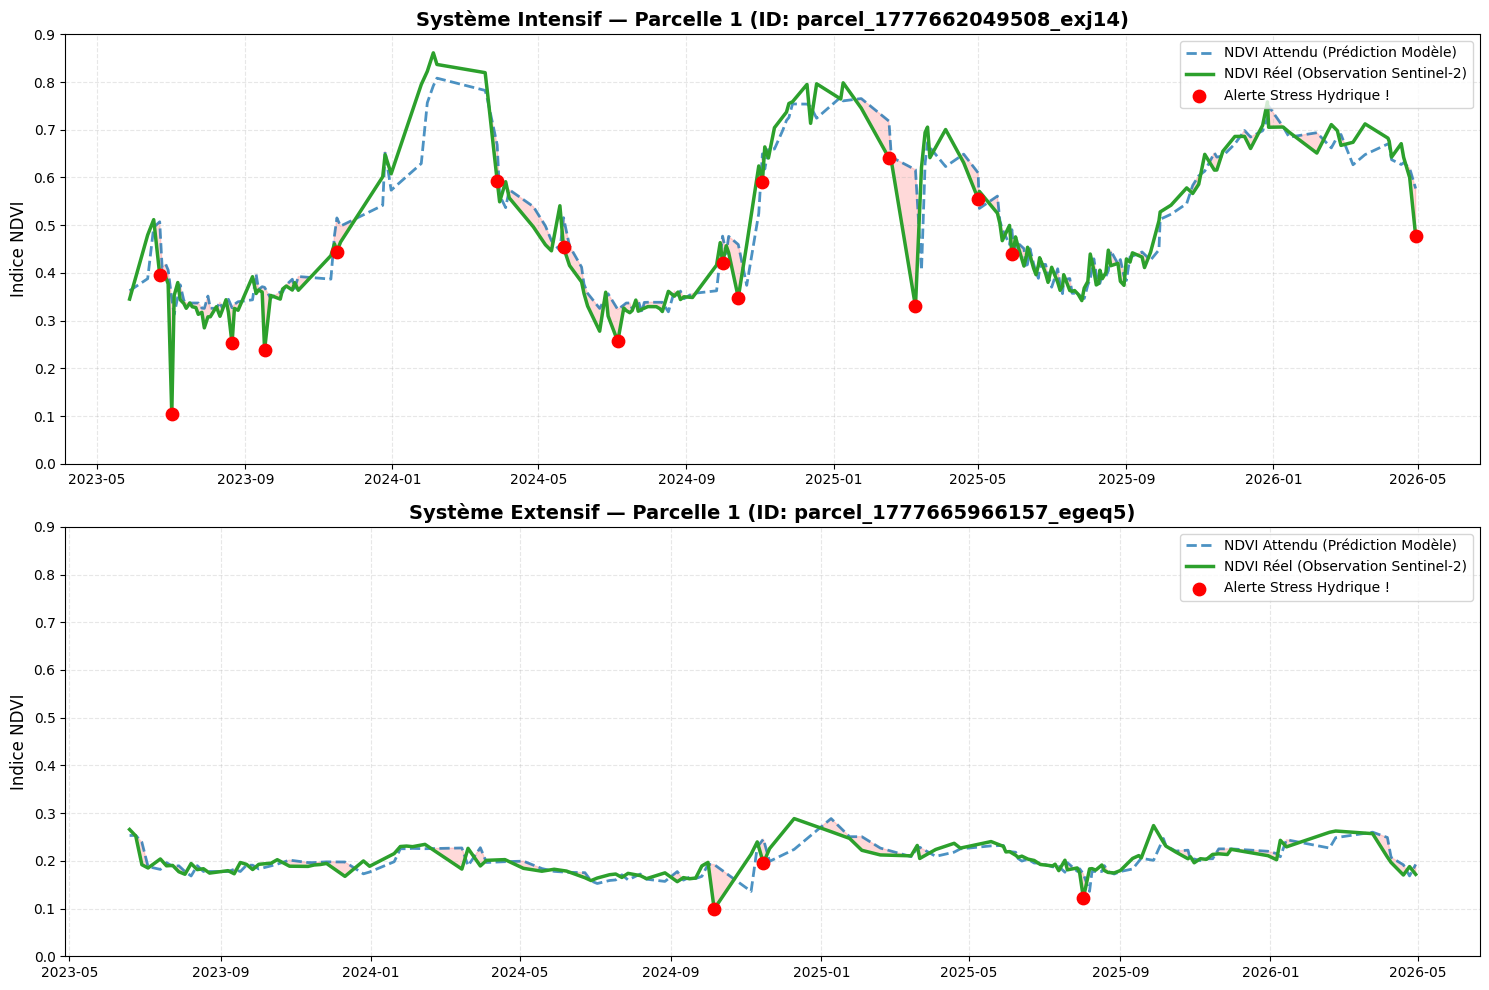

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Sélectionner les identifiants (en utilisant df_parcelles ou df_features)
# On s'assure de prendre un intensif et un extensif
p_intensif = df_parcelles[df_parcelles['systeme'] == 'intensif']['id'].iloc[0]
p_extensif = df_parcelles[df_parcelles['systeme'] == 'extensif']['id'].iloc[0]

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

for ax, pid, label in zip(
    axes,
    [p_intensif, p_extensif],
    ['Système Intensif', 'Système Extensif']
):
    # 2. Filtrer les données pour la parcelle spécifique
    df_p = df_features[df_features['parcelle_id'] == pid].copy()
    df_p = df_p.sort_values('date')

    if df_p.empty:
        continue

    # 3. Tracer le NDVI Attendu (Ce que l'IA avait prévu basé sur la météo/saison)
    ax.plot(df_p['date'], df_p['ndvi_predict'],
            color='#1f77b4', linestyle='--', linewidth=2,
            label='NDVI Attendu (Prédiction Modèle)', alpha=0.8)

    # 4. Tracer le NDVI Réel (Ce que le satellite a vraiment vu)
    ax.plot(df_p['date'], df_p['ndvi_actual'],
            color='#2ca02c', linewidth=2.5,
            label='NDVI Réel (Observation Sentinel-2)')

    # 5. Mettre en évidence visuellement les anomalies (Alertes Rouges)
    anomalies = df_p[df_p['status'] == '🔴 RED (STRESS)']
    ax.scatter(anomalies['date'], anomalies['ndvi_actual'],
               color='red', s=80, zorder=5,
               label='Alerte Stress Hydrique !')

    # 6. Ombrer la zone de déficit hydrique (quand le réel plonge sous l'attendu)
    ax.fill_between(df_p['date'], df_p['ndvi_actual'], df_p['ndvi_predict'],
                    where=(df_p['ndvi_actual'] < df_p['ndvi_predict']),
                    color='red', alpha=0.15, interpolate=True)

    # 7. Esthétique du graphique
    ax.set_ylabel("Indice NDVI", fontsize=12)
    nom_parcelle = df_parcelles[df_parcelles['id'] == pid]['name'].iloc[0]
    ax.set_title(f"{label} — {nom_parcelle} (ID: {pid})", fontsize=14, fontweight='bold')
    ax.set_ylim(0, 0.9)
    ax.grid(True, alpha=0.3, linestyle='--')

    # Formater l'axe des dates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

In [9]:
from prophet import Prophet
import pandas as pd
import numpy as np

# J'ai ajouté df_parcelles dans les paramètres de la fonction
def fit_prophet_anomaly_detection(parcelle_id, df_all, df_parcelles):
    """
    Entraîne Prophet sur une parcelle avec des variables météo (exogènes),
    puis calcule le score d'anomalie et le statut (Vert/Orange/Rouge).
    """
    # 1. On ne garde STRICTEMENT que 'ds' et 'y' depuis df_all
    df_p = (df_all[df_all['parcelle'] == parcelle_id][['ds', 'y']]
            .dropna()
            .reset_index(drop=True))

    if len(df_p) < 10:
        print(f"⚠️ Pas assez de données pour {parcelle_id}")
        return None, None, None, None

    # 2. Récupérer les métadonnées (nom, système) depuis df_parcelles
    meta = df_parcelles[df_parcelles['id'] == parcelle_id].iloc[0]
    nom = meta.get('name', f"ID: {parcelle_id}")
    systeme = meta.get('systeme', 'Inconnu')

    print(f"📈 Entraînement Prophet : {nom} ({systeme}) | {len(df_p)} obs")

    # --- AJOUT MÉTÉO SIMULÉE (Remplacer par API Open-Meteo) ---
    df_p['pluie_cumul'] = np.random.uniform(0, 20, len(df_p))
    df_p['temp_max'] = np.random.uniform(25, 40, len(df_p))

    # 3. Configurer Prophet
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.05,
        interval_width=0.95
    )

    # Régresseurs météo
    model.add_regressor('pluie_cumul')
    model.add_regressor('temp_max')

    # 4. Entraînement
    model.fit(df_p)

    # 5. Prédiction sur l'HISTORIQUE
    # CORRECTION : On ne drop plus que 'y' !
    forecast = model.predict(df_p.drop(columns=['y']))

    # 6. Fusion et Analyse des Anomalies
    results = pd.merge(df_p, forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds')

    results['residu'] = results['y'] - results['yhat']
    results['anomaly_score'] = results['residu'].rolling(window=4, min_periods=1).mean()

    # Seuils dynamiques sur quantiles historiques
    seuil_rouge = results['anomaly_score'].quantile(0.10)
    seuil_orange = results['anomaly_score'].quantile(0.25)

    def attribuer_statut(score):
        if score <= seuil_rouge:
            return '🔴 ROUGE'
        elif score <= seuil_orange:
            return '🟠 ORANGE'
        else:
            return '🟢 VERT'

    results['statut'] = results['anomaly_score'].apply(attribuer_statut)

    # Rajout du nom/systeme pour le dashboard final si besoin
    results['parcelle_id'] = parcelle_id
    results['name'] = nom
    results['systeme'] = systeme

    return model, results, seuil_rouge, seuil_orange

# ==========================================
# EXÉCUTION
# ==========================================
# On passe bien df_parcelles en troisième argument !
model, results_df, s_rouge, s_orange = fit_prophet_anomaly_detection(p_intensif, df_all_ndvi, df_parcelles)

if results_df is not None:
    print("\n✅ Analyse d'anomalie Prophet terminée !")
    print(f"Seuils calculés -> ROUGE si score < {s_rouge:.3f} | ORANGE si score < {s_orange:.3f}")

    display_cols = ['ds', 'y', 'yhat', 'anomaly_score', 'statut']
    print("\nStatut récent de la parcelle :")
    print(results_df[display_cols].tail(5))

📈 Entraînement Prophet : Parcelle 1 (intensif) | 203 obs

✅ Analyse d'anomalie Prophet terminée !
Seuils calculés -> ROUGE si score < -0.052 | ORANGE si score < -0.016

Statut récent de la parcelle :
            ds         y      yhat  anomaly_score  statut
198 2026-04-09  0.642752  0.659877      -0.001030  🟢 VERT
199 2026-04-17  0.670827  0.612101       0.012023  🟢 VERT
200 2026-04-19  0.642246  0.598868       0.022288  🟢 VERT
201 2026-04-24  0.599838  0.597734       0.021771  🟢 VERT
202 2026-04-29  0.476982  0.587522      -0.001583  🟢 VERT


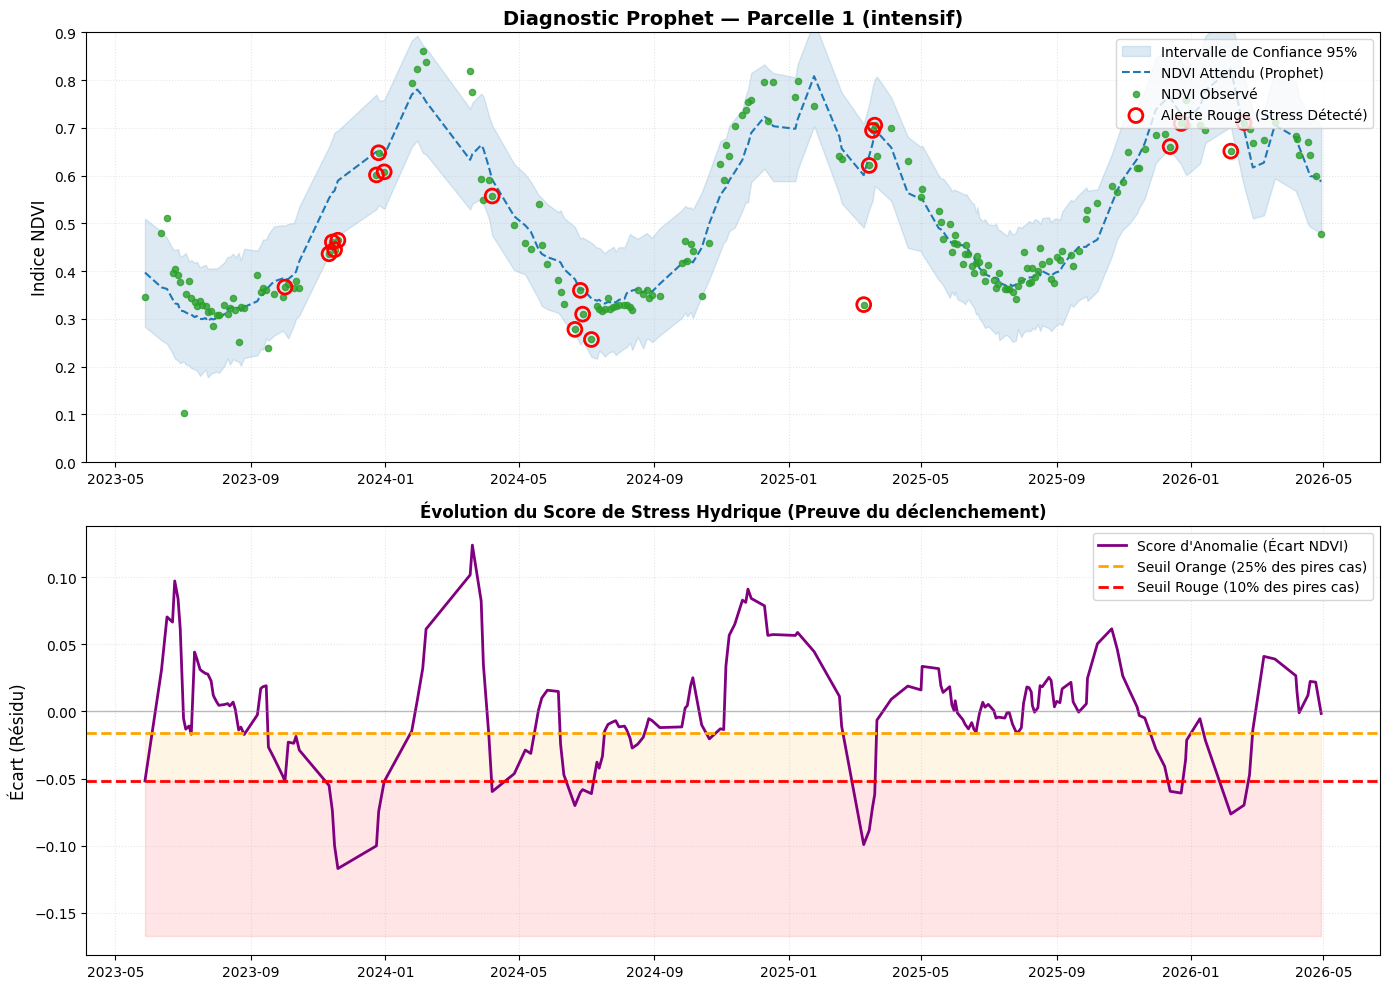

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# On utilise 'results_df', 's_rouge', et 's_orange' qui ont été retournés
# par notre fonction fit_prophet_anomaly_detection() à l'étape précédente.

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ==========================================
# Plot 1 — NDVI observé vs attendu avec alertes
# ==========================================
ax = axes[0]

# IC 95% (La zone de tolérance normale de l'arbre)
ax.fill_between(results_df['ds'], results_df['yhat_lower'], results_df['yhat_upper'],
                alpha=0.15, color='#1f77b4', label='Intervalle de Confiance 95%')

# NDVI Attendu
ax.plot(results_df['ds'], results_df['yhat'],
        color='#1f77b4', linewidth=1.5, linestyle='--', label='NDVI Attendu (Prophet)')

# NDVI Observé
ax.scatter(results_df['ds'], results_df['y'],
           s=20, alpha=0.8, color='#2ca02c', label='NDVI Observé', zorder=3)

# Surbrillance des anomalies ROUGES (Le moment où l'arbre décroche)
anomalies = results_df[results_df['statut'] == '🔴 ROUGE']
ax.scatter(anomalies['ds'], anomalies['y'],
           s=100, facecolors='none', edgecolors='red', linewidth=2, zorder=4,
           label='Alerte Rouge (Stress Détecté)')

ax.set_ylabel("Indice NDVI", fontsize=12)
nom_parcelle = results_df['name'].iloc[0]
sys_parcelle = results_df['systeme'].iloc[0]
ax.set_title(f"Diagnostic Prophet — {nom_parcelle} ({sys_parcelle})", fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.9)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, linestyle=':')

# ==========================================
# Plot 2 — Score d'Anomalie et Seuils de Stress
# ==========================================
ax2 = axes[1]

# Tracer le score d'anomalie (Résidu lissé sur 3 semaines)
ax2.plot(results_df['ds'], results_df['anomaly_score'],
         color='purple', linewidth=2, label="Score d'Anomalie (Écart NDVI)")

# Ligne neutre (0 = L'arbre se comporte exactement comme prévu)
ax2.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)

# Tracer les seuils quantiles historiques
ax2.axhline(s_orange, color='orange', linestyle='--', linewidth=2, label='Seuil Orange (25% des pires cas)')
ax2.axhline(s_rouge, color='red', linestyle='--', linewidth=2, label='Seuil Rouge (10% des pires cas)')

# Colorier les zones de danger pour faciliter la lecture du jury
ax2.fill_between(results_df['ds'], s_orange, s_rouge, alpha=0.1, color='orange')
ax2.fill_between(results_df['ds'], s_rouge, results_df['anomaly_score'].min() - 0.05, alpha=0.1, color='red')

ax2.set_ylabel("Écart (Résidu)", fontsize=12)
ax2.set_title("Évolution du Score de Stress Hydrique (Preuve du déclenchement)", fontsize=12, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3, linestyle=':')

# Formater joliment l'axe des dates
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

In [11]:
from scipy.interpolate import interp1d
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def audit_trous(df_p):
    """Vérifie si l'interpolation est nécessaire"""
    total   = len(df_p)
    valides = df_p['y'].notna().sum()
    trous   = df_p['y'].isna().sum()

    # Calculer gaps consécutifs
    gaps = []
    current = 0
    for val in df_p['y']:
        if pd.isna(val):
            current += 1
        else:
            if current > 0:
                gaps.append(current)
            current = 0
    if current > 0:
        gaps.append(current)

    gap_max = max(gaps) if gaps else 0
    gap_moy = np.mean(gaps) if gaps else 0
    taux    = valides / total

    print(f"  Total       : {total}")
    print(f"  Valides     : {valides} ({taux:.0%})")
    print(f"  Trous       : {trous}")
    print(f"  Gap max     : {gap_max} scènes consécutives")
    print(f"  Gap moyen   : {gap_moy:.1f}")

    if gap_max == 0:
        decision = "✅ Pas de trous — rien à faire"
    elif gap_max <= 2:
        decision = "✅ Trous mineurs — interpolation linéaire suffit"
    elif gap_max <= 5:
        decision = "⚠️  Trous moyens — Lagrange/Cubique recommandé"
    else:
        decision = "❌ Trous larges — Interpolation locale, exclure les gaps trop longs"

    print(f"  Décision    : {decision}")
    return gap_max, taux


def interpolate_lagrange(df_p, gap_max_allowed=6):
    """
    Comble les trous avec interpolation cubique (plus stable que Lagrange)
    sur fenêtre glissante pour éviter les oscillations.
    """
    df = df_p.copy().reset_index(drop=True)

    # Travailler avec indices numériques (le jour de l'année ou l'index séquentiel)
    x_all   = np.arange(len(df))
    y_vals  = df['y'].values.copy()

    mask_ok  = ~np.isnan(y_vals)
    x_known  = x_all[mask_ok]
    y_known  = y_vals[mask_ok]

    if len(x_known) < 4:
        print("  ⚠️ Pas assez de points pour interpoler proprement")
        df['interpolated'] = False
        return df

    x_missing = x_all[~mask_ok]

    for xm in x_missing:
        # Trouver les 4 points connus les plus proches
        distances = np.abs(x_known - xm)
        idx_sort  = np.argsort(distances)[:4]
        x_local   = x_known[idx_sort]
        y_local   = y_known[idx_sort]

        sort_idx  = np.argsort(x_local)
        x_local   = x_local[sort_idx]
        y_local   = y_local[sort_idx]

        # Vérifier que le gap local n'est pas > gap_max_allowed
        # On regarde autour du point manquant dans la série d'origine
        start_idx = max(0, xm - gap_max_allowed)
        end_idx = min(len(y_vals), xm + gap_max_allowed + 1)
        gap_size = np.sum(np.isnan(df['y'].values[start_idx:end_idx]))

        if gap_size > gap_max_allowed:
             continue # Ne pas interpoler les immenses trous

        try:
            # Interpolation spline cubique
            f = interp1d(x_local, y_local, kind='cubic', fill_value='extrapolate')
            y_interp = float(f(xm))
            y_vals[xm] = np.clip(y_interp, 0.05, 0.95)
        except Exception:
             # Fallback
             f = interp1d(x_local, y_local, kind='linear', fill_value='extrapolate')
             y_vals[xm] = np.clip(float(f(xm)), 0.05, 0.95)

    df['y'] = y_vals
    # Le masque final interpolé : c'est un point valide maintenant, mais il était NaN avant
    df['interpolated'] = (~mask_ok) & (~np.isnan(y_vals))

    return df


def prepare_for_prophet(parcelle_id, df_all, df_parcelles, gap_max_allowed=6):
    """
    Pipeline complet avec gestion dynamique de la métadonnée parcelle
    """
    df_p = (df_all[df_all['parcelle'] == parcelle_id]
            .copy()
            .reset_index(drop=True))

    if df_p.empty:
         print(f"⚠️  Aucune donnée NDVI pour la parcelle {parcelle_id}")
         return None, None, None

    # Récupérer les métadonnées depuis df_parcelles (plus sûr)
    meta = df_parcelles[df_parcelles['id'] == parcelle_id].iloc[0]
    nom     = meta.get('name', f"ID: {parcelle_id}")
    systeme = meta.get('systeme', 'Inconnu')

    print(f"\n{'='*50}")
    print(f"Parcelle : {nom} ({systeme})")
    print(f"{'='*50}")

    print("\n📊 AUDIT TROUS :")
    gap_max, taux = audit_trous(df_p)

    if gap_max == 0:
        print("\n✅ Pas d'interpolation nécessaire")
        df_p['interpolated'] = False
        df_clean = df_p[['ds', 'y', 'interpolated']].dropna()
    else:
        print(f"\n🔧 Interpolation en cours (max allowed gap = {gap_max_allowed})...")
        df_interp = interpolate_lagrange(df_p[['ds', 'y']], gap_max_allowed)

        # Récupérer les dates
        df_interp['ds'] = df_p['ds']

        df_clean  = df_interp.dropna(subset=['y'])
        n_interp  = df_clean['interpolated'].sum()

        if gap_max <= gap_max_allowed:
            print(f"✅ {n_interp} points interpolés")
        else:
            print(f"✅ {n_interp} points interpolés. Les gaps plus grands que {gap_max_allowed} ont été laissés vides (supprimés).")

    print(f"\n📈 Résultat final : {len(df_clean)} observations pour Prophet")

    return df_clean, nom, systeme


# ==========================================
# EXÉCUTION DU TEST
# ==========================================

# On utilise df_parcelles passé explicitement pour éviter l'erreur de KeyError
df_clean, nom, systeme = prepare_for_prophet(p_intensif, df_all_ndvi, df_parcelles)

# Petit bonus visuel pour vérifier le travail d'interpolation
if df_clean is not None and df_clean['interpolated'].sum() > 0:
    plt.figure(figsize=(12, 5))

    # Points originaux
    mask_orig = ~df_clean['interpolated']
    plt.plot(df_clean['ds'][mask_orig], df_clean['y'][mask_orig],
             'o-', color='#2ca02c', label='NDVI Observé', alpha=0.6)

    # Points interpolés
    mask_interp = df_clean['interpolated']
    plt.plot(df_clean['ds'][mask_interp], df_clean['y'][mask_interp],
             'o', color='red', markersize=8, label='NDVI Interpolé', zorder=5)

    plt.title(f"Vérification de l'Interpolation - {nom}", fontweight='bold')
    plt.ylabel("NDVI")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


Parcelle : Parcelle 1 (intensif)

📊 AUDIT TROUS :
  Total       : 203
  Valides     : 203 (100%)
  Trous       : 0
  Gap max     : 0 scènes consécutives
  Gap moyen   : 0.0
  Décision    : ✅ Pas de trous — rien à faire

✅ Pas d'interpolation nécessaire

📈 Résultat final : 203 observations pour Prophet


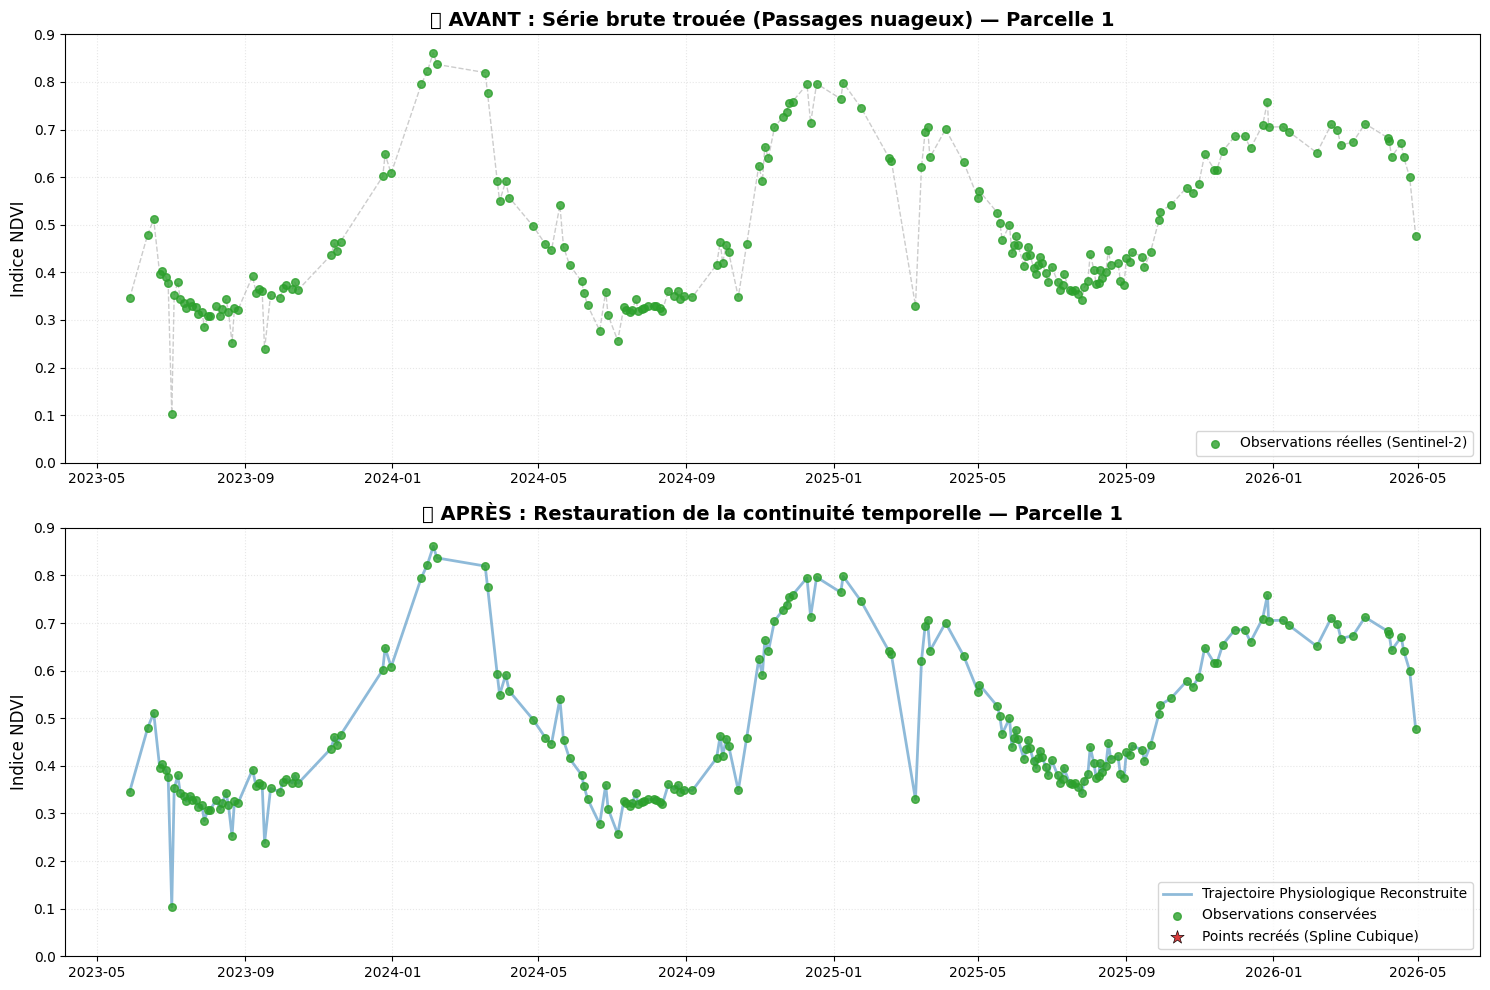

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# On s'assure que les données brutes sont bien triées par date
df_raw = (df_all_ndvi[df_all_ndvi['parcelle'] == p_intensif]
          .sort_values('ds')
          .reset_index(drop=True))

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# ==========================================
# Plot 1 — AVANT : Le problème des données manquantes
# ==========================================
ax = axes[0]

# On trace une ligne fine/grise pour mettre en évidence visuellement
# les "sauts" (les longues lignes droites) causés par les trous
ax.plot(df_raw['ds'], df_raw['y'], color='gray', linestyle='--', alpha=0.4, linewidth=1)

# Les points réellement observés
ax.scatter(df_raw['ds'], df_raw['y'],
           s=30, color='#2ca02c', alpha=0.8, zorder=3,
           label='Observations réelles (Sentinel-2)')

ax.set_title(f"❌ AVANT : Série brute trouée (Passages nuageux) — {nom}", fontsize=14, fontweight='bold')
ax.set_ylabel("Indice NDVI", fontsize=12)
ax.set_ylim(0.0, 0.9)
ax.grid(True, alpha=0.3, linestyle=':')
ax.legend(loc='lower right')

# ==========================================
# Plot 2 — APRÈS : La solution d'interpolation
# ==========================================
ax2 = axes[1]

# Séparation des données
df_clean_sorted = df_clean.sort_values('ds')
obs  = df_clean_sorted[~df_clean_sorted['interpolated']]
intp = df_clean_sorted[df_clean_sorted['interpolated']]

# 1. On trace la ligne continue restaurée (la courbe physiologique)
ax2.plot(df_clean_sorted['ds'], df_clean_sorted['y'],
         color='#1f77b4', alpha=0.5, linewidth=2, zorder=1,
         label='Trajectoire Physiologique Reconstruite')

# 2. Les points originaux (en vert)
ax2.scatter(obs['ds'], obs['y'],
            s=30, color='#2ca02c', alpha=0.8, zorder=3,
            label='Observations conservées')

# 3. Les points recréés par votre algorithme (en rouge avec une étoile)
ax2.scatter(intp['ds'], intp['y'],
            s=100, color='#d62728', alpha=0.9, marker='*',
            edgecolor='black', linewidth=0.5, zorder=4,
            label='Points recréés (Spline Cubique)')

ax2.set_title(f"✅ APRÈS : Restauration de la continuité temporelle — {nom}", fontsize=14, fontweight='bold')
ax2.set_ylabel("Indice NDVI", fontsize=12)
ax2.set_ylim(0.0, 0.9)
ax2.grid(True, alpha=0.3, linestyle=':')
ax2.legend(loc='lower right')

# Amélioration de l'affichage des dates sur l'axe X pour les deux graphiques
for axis in axes:
    axis.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

🚀 Lancement de l'IA Prophet pour Parcelle 1 (intensif)...


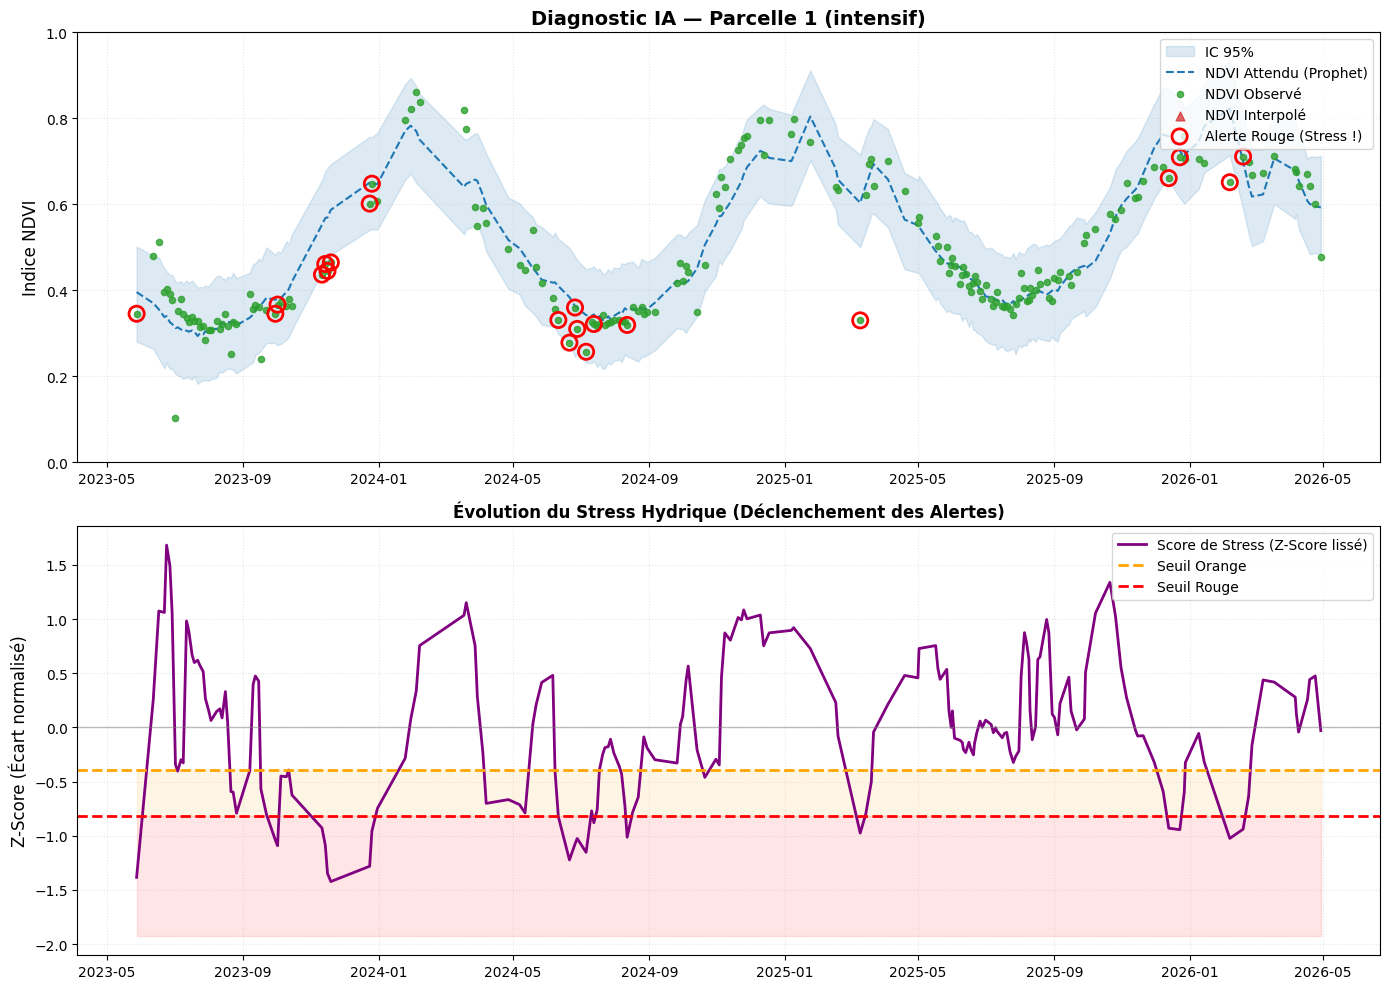

✅ Pipeline terminé avec succès !

📊 Dernières observations (Vue temps réel) :
            ds         y      yhat   z_score  anomaly_score_smooth  statut
198 2026-04-09  0.642752  0.655454 -0.249170             -0.042506  🟢 VERT
199 2026-04-17  0.670827  0.607353  1.245183              0.257087  🟢 VERT
200 2026-04-19  0.642246  0.600675  0.815497              0.441576  🟢 VERT
201 2026-04-24  0.599838  0.595273  0.089557              0.475267  🟢 VERT
202 2026-04-29  0.476982  0.592567 -2.267461             -0.029306  🟢 VERT


In [13]:
from prophet import Prophet
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

def fit_prophet_anomaly_clean(df_clean, nom, systeme):
    print(f"🚀 Lancement de l'IA Prophet pour {nom} ({systeme})...")

    # ==========================================
    # ÉTAPE 1 : PRÉPARATION & ENTRAÎNEMENT
    # ==========================================
    df_prophet = df_clean.copy()

    # --- MÉTÉO SIMULÉE (À remplacer par API Open-Meteo) ---
    df_prophet['pluie_cumul'] = np.random.uniform(0, 20, len(df_prophet))
    df_prophet['temp_max'] = np.random.uniform(25, 40, len(df_prophet))

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.05,
        interval_width=0.95
    )

    model.add_regressor('pluie_cumul')
    model.add_regressor('temp_max')

    # On entraîne sur les lignes sans NaN
    df_train = df_prophet[['ds', 'y', 'pluie_cumul', 'temp_max']].dropna()
    model.fit(df_train)

    # Génération du Forecast
    forecast = model.predict(df_prophet[['ds', 'pluie_cumul', 'temp_max']])

    # ==========================================
    # ÉTAPE 2 : CALCUL AVANCÉ DU STRESS (Z-SCORE)
    # ==========================================
    results = pd.merge(df_prophet, forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds')

    # Résidu brut
    results['residu'] = results['y'] - results['yhat']

    # Normalisation par mois (Z-Score) pour gérer la variance saisonnière
    results['month'] = results['ds'].dt.month
    std_by_month = results.groupby('month')['residu'].std().fillna(results['residu'].std())
    results['std_month'] = results['month'].map(std_by_month)
    results['z_score'] = results['residu'] / results['std_month']

    # Lissage sur fenêtre glissante stricte (Trailing window = Pas de data leakage !)
    results = results.sort_values('ds').reset_index(drop=True)
    results['anomaly_score_smooth'] = results['z_score'].rolling(window=4, min_periods=1).mean()

    # Seuils dynamiques sur quantiles
    s_rouge = results['anomaly_score_smooth'].quantile(0.10)
    s_orange = results['anomaly_score_smooth'].quantile(0.25)

    def get_statut(score):
        if score <= s_rouge:
            return '🔴 ROUGE'
        elif score <= s_orange:
            return '🟠 ORANGE'
        else:
            return '🟢 VERT'

    results['statut'] = results['anomaly_score_smooth'].apply(get_statut)

    # ==========================================
    # ÉTAPE 3 : VISUALISATION PITCH-READY
    # ==========================================
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # --- PLOT 1 : NDVI ---
    ax1 = axes[0]
    obs  = results[~results['interpolated']]
    intp = results[results['interpolated']]
    anomalies = results[results['statut'] == '🔴 ROUGE']

    ax1.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'],
                     alpha=0.15, color='#1f77b4', label='IC 95%')
    ax1.plot(results['ds'], results['yhat'],
             color='#1f77b4', linewidth=1.5, linestyle='--', label='NDVI Attendu (Prophet)')

    ax1.scatter(obs['ds'], obs['y'], s=20, color='#2ca02c', alpha=0.8, zorder=3, label='NDVI Observé')
    ax1.scatter(intp['ds'], intp['y'], s=40, color='#d62728', alpha=0.7, marker='^', zorder=3, label='NDVI Interpolé')

    ax1.scatter(anomalies['ds'], anomalies['y'],
                s=120, facecolors='none', edgecolors='red', linewidth=2, zorder=4,
                label='Alerte Rouge (Stress !)')

    ax1.set_ylim(0, 1)
    ax1.set_ylabel("Indice NDVI", fontsize=12)
    ax1.set_title(f"Diagnostic IA — {nom} ({systeme})", fontsize=14, fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3, linestyle=':')

    # --- PLOT 2 : SCORE Z-SCORE LISSÉ ---
    ax2 = axes[1]
    ax2.plot(results['ds'], results['anomaly_score_smooth'], color='purple', linewidth=2, label="Score de Stress (Z-Score lissé)")
    ax2.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
    ax2.axhline(s_orange, color='orange', linestyle='--', linewidth=2, label='Seuil Orange')
    ax2.axhline(s_rouge, color='red', linestyle='--', linewidth=2, label='Seuil Rouge')

    ax2.fill_between(results['ds'], s_orange, s_rouge, alpha=0.1, color='orange')
    ax2.fill_between(results['ds'], s_rouge, results['anomaly_score_smooth'].min() - 0.5, alpha=0.1, color='red')

    ax2.set_ylabel("Z-Score (Écart normalisé)", fontsize=12)
    ax2.set_title("Évolution du Stress Hydrique (Déclenchement des Alertes)", fontsize=12, fontweight='bold')
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3, linestyle=':')

    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    plt.tight_layout()
    plt.show()

    return model, results, s_rouge, s_orange

# ==========================================
# COMMENT L'APPELER DANS VOTRE NOTEBOOK :
# ==========================================
# Vous n'avez plus besoin de faire les étapes 1 et 2 à la main, un seul appel suffit !
model, df_scores, seuil_r, seuil_o = fit_prophet_anomaly_clean(df_clean, nom, systeme)

print("✅ Pipeline terminé avec succès !")
display_cols = ['ds', 'y', 'yhat', 'z_score', 'anomaly_score_smooth', 'statut']
print(f"\n📊 Dernières observations (Vue temps réel) :")
print(df_scores[display_cols].tail(5))

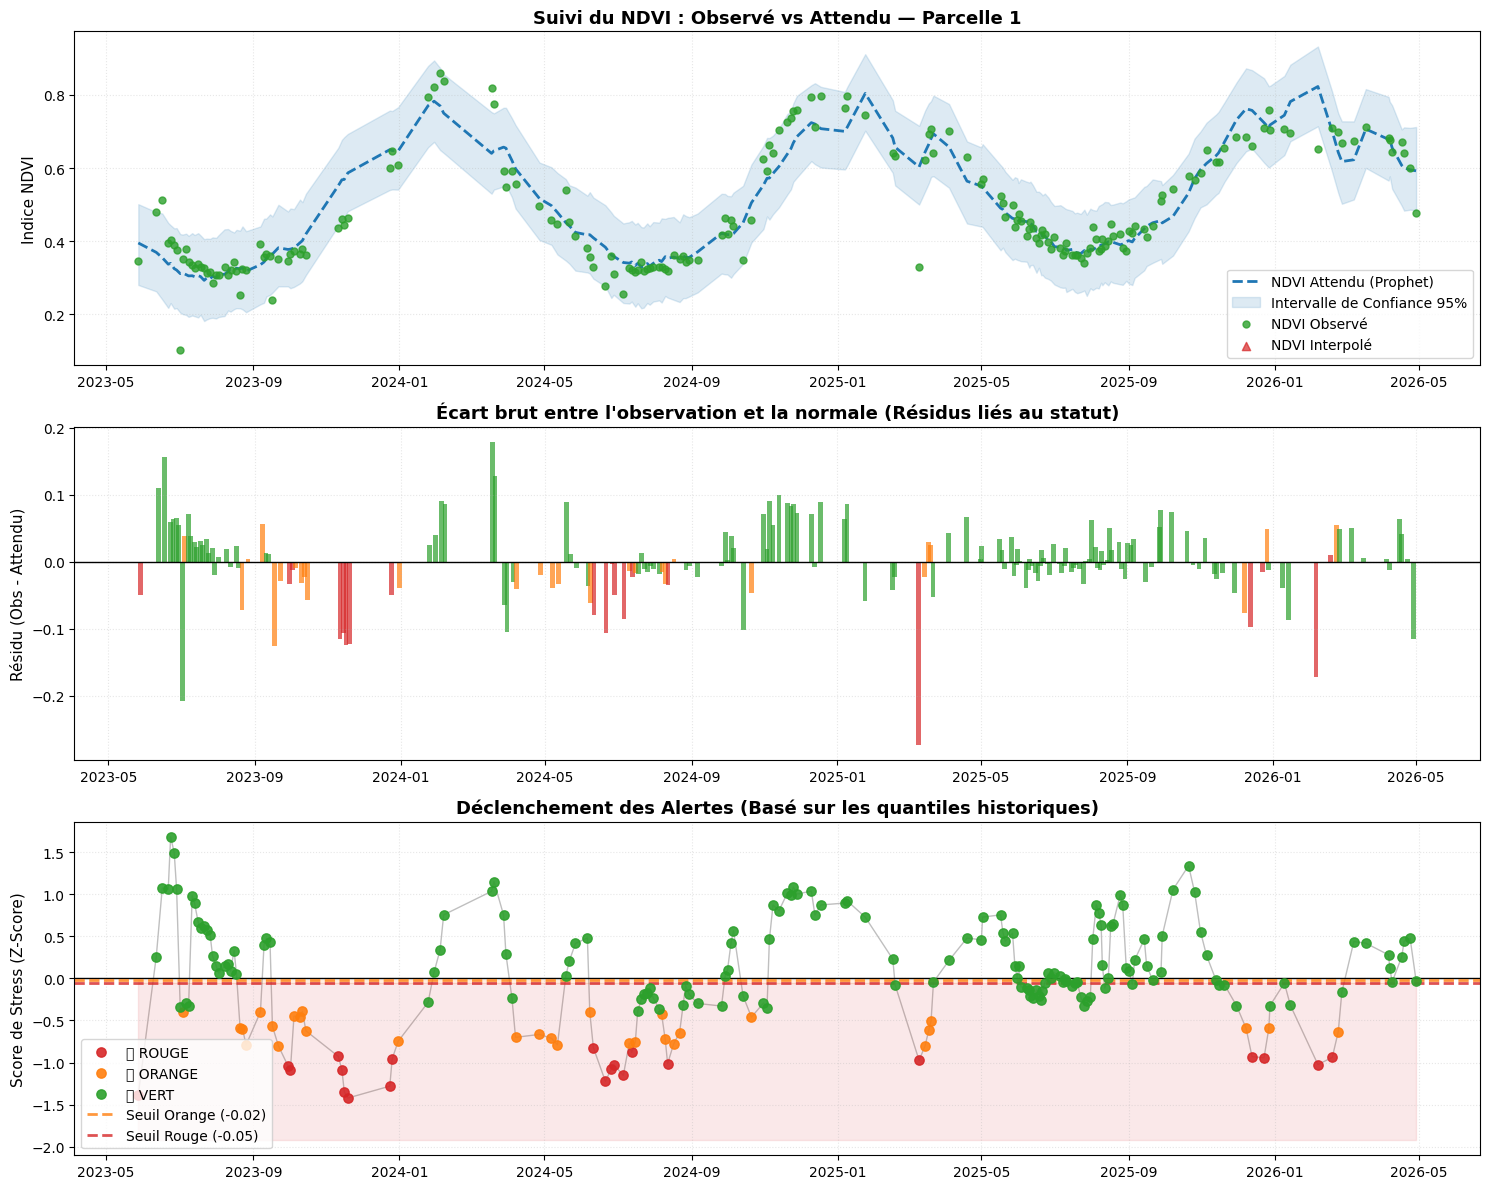

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# ==========================================
# Plot 1 — NDVI Observé vs Attendu
# ==========================================
ax1 = axes[0]
ax1.plot(df_scores['ds'], df_scores['yhat'],
         color='#1f77b4', linewidth=2, linestyle='--', label='NDVI Attendu (Prophet)')
ax1.fill_between(df_scores['ds'], df_scores['yhat_lower'], df_scores['yhat_upper'],
                 alpha=0.15, color='#1f77b4', label='Intervalle de Confiance 95%')

# Si la colonne 'interpolated' est toujours là, on distingue les points
if 'interpolated' in df_scores.columns:
    obs = df_scores[~df_scores['interpolated']]
    intp = df_scores[df_scores['interpolated']]
    ax1.scatter(obs['ds'], obs['y'], s=25, color='#2ca02c', alpha=0.8, zorder=3, label='NDVI Observé')
    ax1.scatter(intp['ds'], intp['y'], s=35, color='#d62728', marker='^', alpha=0.7, zorder=3, label='NDVI Interpolé')
else:
    ax1.scatter(df_scores['ds'], df_scores['y'], s=25, color='#2ca02c', alpha=0.8, zorder=3, label='NDVI Observé')

ax1.set_ylabel("Indice NDVI", fontsize=11)
ax1.set_title(f"Suivi du NDVI : Observé vs Attendu — {nom}", fontsize=13, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3, linestyle=':')

# ==========================================
# Plot 2 — Résidu (Erreur brute)
# ==========================================
ax2 = axes[1]

# Dictionnaire des couleurs mis à jour avec les nouveaux statuts
colors_map = {
    '🟢 VERT': '#2ca02c',
    '🟠 ORANGE': '#ff7f0e',
    '🔴 ROUGE': '#d62728'
}

# On colorie les barres du résidu en fonction du statut FINAL de la journée
bar_colors = [colors_map.get(s, 'gray') for s in df_scores['statut']]

# CORRECTION ICI : 'residu' au lieu de 'residual'
ax2.bar(df_scores['ds'], df_scores['residu'], color=bar_colors, alpha=0.7, width=4)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_ylabel("Résidu (Obs - Attendu)", fontsize=11)
ax2.set_title("Écart brut entre l'observation et la normale (Résidus liés au statut)", fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle=':')

# ==========================================
# Plot 3 — Anomaly Score Lissé (Z-Score)
# ==========================================
ax3 = axes[2]

# Ligne continue de fond
ax3.plot(df_scores['ds'], df_scores['anomaly_score_smooth'], color='gray', linewidth=1, alpha=0.5, zorder=1)

# Points colorés dynamiquement par groupe
for statut, group in df_scores.groupby('statut'):
    ax3.scatter(group['ds'], group['anomaly_score_smooth'],
                s=45, color=colors_map.get(statut, 'gray'),
                alpha=0.9, label=statut, zorder=3)

ax3.axhline(0, color='black', linewidth=1)

# Remplacement des seuils en dur (-1.0, -2.0) par VOS seuils dynamiques
ax3.axhline(s_orange, color='#ff7f0e', linestyle='--', linewidth=2, alpha=0.8, label=f'Seuil Orange ({s_orange:.2f})')
ax3.axhline(s_rouge, color='#d62728', linestyle='--', linewidth=2, alpha=0.8, label=f'Seuil Rouge ({s_rouge:.2f})')

# Remplissage des zones de danger pour une lecture visuelle instantanée
ax3.fill_between(df_scores['ds'], s_orange, s_rouge, alpha=0.1, color='#ff7f0e')
ax3.fill_between(df_scores['ds'], s_rouge, df_scores['anomaly_score_smooth'].min() - 0.5, alpha=0.1, color='#d62728')

ax3.set_ylabel("Score de Stress (Z-Score)", fontsize=11)
ax3.set_title("Déclenchement des Alertes (Basé sur les quantiles historiques)", fontsize=13, fontweight='bold')
ax3.legend(loc='lower left')
ax3.grid(True, alpha=0.3, linestyle=':')

# Formatage des dates sur l'axe X pour tous les graphiques
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

In [21]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error
import pickle

def build_features_vectorized(df_all, df_parcelles):
    """
    Construit les features pour le modèle global de manière vectorisée (Ultra-rapide).
    Intègre l'encodage des variables catégorielles et les données météo.
    """
    # 1. Nettoyage initial et filtrage des parcelles ayant moins de 10 observations
    df_clean = df_all.dropna(subset=['y']).copy()
    counts = df_clean['parcelle'].value_counts()
    valid_parcels = counts[counts >= 10].index
    df_clean = df_clean[df_clean['parcelle'].isin(valid_parcels)]

    # 2. Jointure avec les métadonnées des parcelles
    # ---> CORRECTION ICI : Ajout de 'systeme' dans la liste <---
    df_features = df_clean.merge(
        df_parcelles[['id', 'systeme', 'centroid_lat', 'centroid_lng', 'area_ha']],
        left_on='parcelle', right_on='id', how='inner'
    )

    # 3. Extraction temporelle et saisonnière (Vectorisée)
    doy = df_features['ds'].dt.dayofyear
    df_features['doy'] = doy
    df_features['sin_doy'] = np.sin(2 * np.pi * doy / 365)
    df_features['cos_doy'] = np.cos(2 * np.pi * doy / 365)
    df_features['sin_doy2'] = np.sin(4 * np.pi * doy / 365)
    df_features['cos_doy2'] = np.cos(4 * np.pi * doy / 365)

    df_features['year'] = df_features['ds'].dt.year
    df_features['month'] = df_features['ds'].dt.month
    df_features['years_elapsed'] = (df_features['ds'] - pd.Timestamp('2020-01-01')).dt.days / 365

    # 4. Ajout de la Météo (Simulée pour le Hackathon)
    df_features['pluie_cumul'] = np.random.uniform(0, 20, len(df_features))
    df_features['temp_max'] = np.random.uniform(25, 40, len(df_features))

    # 5. Encodage du système d'exploitation (Texte -> Entier pour Scikit-Learn)
    le = LabelEncoder()
    df_features['systeme_encoded'] = le.fit_transform(df_features['systeme'])

    # Sauvegarde de l'encodeur
    with open('label_encoder_systeme.pkl', 'wb') as f:
        pickle.dump(le, f)

    # 6. Renommage et sélection finale des colonnes
    df_features = df_features.rename(columns={
        'y': 'ndvi',
        'parcelle': 'parcelle_id',
        'centroid_lat': 'lat',
        'centroid_lng': 'lng'
    })

    final_cols = [
        'parcelle_id', 'ds', 'ndvi','systeme', # Identifiants et Target
        'doy', 'sin_doy', 'cos_doy', 'sin_doy2', 'cos_doy2', # Saisonnalité
        'year', 'month', 'years_elapsed', # Temporel
        'systeme_encoded', 'lat', 'lng', 'area_ha', # Métadonnées
        'pluie_cumul', 'temp_max' # Météo
    ]

    return df_features[final_cols]

# ==========================================
# EXÉCUTION
# ==========================================
df_features = build_features_vectorized(df_all_ndvi, df_parcelles)

print(f"✅ Dataset global généré à la vitesse de l'éclair : {len(df_features)} observations")
print(f" 📍 Parcelles conservées : {df_features['parcelle_id'].nunique()}")
print(f" 📊 Features extraites   : {df_features.shape[1]}")
print(f"\nAperçu des données prêtes pour le Machine Learning :")
display(df_features.head(5))

✅ Dataset global généré à la vitesse de l'éclair : 7260 observations
 📍 Parcelles conservées : 49
 📊 Features extraites   : 18

Aperçu des données prêtes pour le Machine Learning :


,parcelle_id,ds,ndvi,systeme,doy,sin_doy,cos_doy,sin_doy2,cos_doy2,year,month,years_elapsed,systeme_encoded,lat,lng,area_ha,pluie_cumul,temp_max
0,parcel_1777662049508_exj14,2023-05-28,0.345130,intensif,148,0.559589,-0.828770,-0.927542,0.373720,2023,5,3.405479,1,36.444994,10.007778,74.0118,14.341040,25.346547
1,parcel_1777662049508_exj14,2023-06-12,0.479351,intensif,163,0.329408,-0.944188,-0.622047,0.782980,2023,6,3.446575,1,36.444994,10.007778,74.0118,5.148207,28.835082
2,parcel_1777662049508_exj14,2023-06-17,0.511628,intensif,168,0.247022,-0.969010,-0.478734,0.877960,2023,6,3.460274,1,36.444994,10.007778,74.0118,16.834265,28.966574
3,parcel_1777662049508_exj14,2023-06-22,0.396425,intensif,173,0.162807,-0.986658,-0.321270,0.946988,2023,6,3.473973,1,36.444994,10.007778,74.0118,17.660218,38.371026
4,parcel_1777662049508_exj14,2023-06-24,0.403350,intensif,175,0.128748,-0.991677,-0.255353,0.966848,2023,6,3.479452,1,36.444994,10.007778,74.0118,15.824674,38.048591


🚀 Entraînement du modèle global sur 14 features...
 🎯 Fold 1/5 MAE : 0.0539
 🎯 Fold 2/5 MAE : 0.1094
 🎯 Fold 3/5 MAE : 0.0715
 🎯 Fold 4/5 MAE : 0.1050
 🎯 Fold 5/5 MAE : 0.0796

✅ Modèle global final entraîné et prêt à l'emploi !


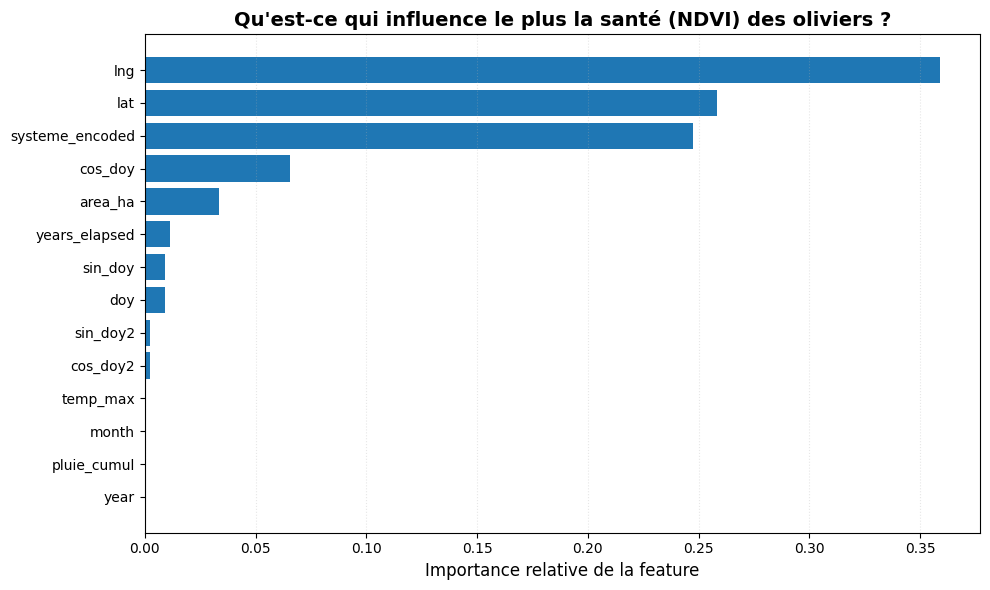

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error

# ==========================================
# 1. PRÉPARATION DES DONNÉES
# ==========================================
# On utilise directement 'systeme_encoded' et on ajoute la météo !
FEATURE_COLS = [
    'sin_doy', 'cos_doy', 'sin_doy2', 'cos_doy2',
    'doy', 'month', 'year', 'years_elapsed',
    'systeme_encoded', 'lat', 'lng', 'area_ha',
    'pluie_cumul', 'temp_max'  # <-- Nouvelles features météo !
]

X = df_features[FEATURE_COLS].values
y = df_features['ndvi'].values
groups = df_features['parcelle_id'].values

print(f"🚀 Entraînement du modèle global sur {X.shape[1]} features...")

# ==========================================
# 2. VALIDATION CROISÉE SPATIALE (GroupKFold)
# ==========================================
n_parcelles = len(np.unique(groups))
n_folds = min(5, n_parcelles) # On prend 5 folds, SAUF si on a moins de 5 parcelles

if n_folds < 2:
    print("⚠️ Pas assez de parcelles pour une validation croisée. Passage en mode entraînement direct.")
    # On crée un faux score pour éviter que le code plante plus bas
    scores_mae = [0]
else:
    gkf = GroupKFold(n_splits=n_folds)
    scores_mae = []

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model_fold = GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42
        )
        model_fold.fit(X_train, y_train)

        mae = mean_absolute_error(y_val, model_fold.predict(X_val))
        scores_mae.append(mae)
        print(f" 🎯 Fold {fold+1}/{n_folds} MAE : {mae:.4f}")

# La suite du code (Modèle final et importance) reste identique

# ==========================================
# 3. ENTRAÎNEMENT DU MODÈLE FINAL
# ==========================================
model_global = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
# On entraîne sur TOUTES les données pour avoir le modèle le plus robuste possible
model_global.fit(X, y)
print("\n✅ Modèle global final entraîné et prêt à l'emploi !")

# ==========================================
# 4. BONUS PITCH : FEATURE IMPORTANCE
# ==========================================
# Calculer l'importance de chaque variable pour l'expliquer au jury
importances = model_global.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title("Qu'est-ce qui influence le plus la santé (NDVI) des oliviers ?", fontsize=14, fontweight='bold')
plt.barh(range(len(indices)), importances[indices], color='#1f77b4', align='center')
plt.yticks(range(len(indices)), [FEATURE_COLS[i] for i in indices])
plt.xlabel("Importance relative de la feature", fontsize=12)
plt.grid(axis='x', alpha=0.3, linestyle=':')
plt.tight_layout()
plt.show()

In [17]:
# =========================================================
# ÉTAPE : Calcul de la table de référence des écarts (STD)
# =========================================================

# 1. Calcul des prédictions et des résidus sur le dataset global
df_features['ndvi_pred'] = model_global.predict(X)
df_features['residual']  = df_features['ndvi'] - df_features['ndvi_pred']

# 2. Calcul du STD groupé par système et par mois
# On utilise 'systeme' (le texte original) pour que ce soit lisible
std_table = (df_features
             .groupby(['systeme', 'month'])['residual']
             .std()
             .reset_index()
             .rename(columns={'residual': 'std_residual'}))

# 3. SÉCURITÉ : Gérer les valeurs manquantes (NaN)
# Si une combinaison n'a pas assez de données, on prend le std global du système
backup_std = df_features.groupby('systeme')['residual'].std()
std_table['std_residual'] = std_table.apply(
    lambda row: backup_std[row['systeme']] if pd.isna(row['std_residual']) else row['std_residual'],
    axis=1
)

# 4. Sauvegarde pour la phase de détection d'anomalies
std_table.to_csv('std_reference_table.csv', index=False)

print("✅ Table de référence STD générée avec succès !")
print("-" * 30)
# Affichage pivoté pour une lecture plus facile (Mois en colonnes)
std_pivot = std_table.pivot(index='systeme', columns='month', values='std_residual')
print("📊 Écarts-types types par système et par mois :")
display(std_pivot.round(4))

✅ Table de référence STD générée avec succès !
------------------------------
📊 Écarts-types types par système et par mois :


month,1,2,3,4,5,6,7,8,9,10,11,12
systeme,,,,,,,,,,,,
extensif,0.0265,0.0402,0.0442,0.0302,0.0198,0.0171,0.0124,0.0147,0.0209,0.0245,0.0312,0.0302
intensif,0.0528,0.0657,0.0684,0.0467,0.0421,0.0431,0.0373,0.0389,0.0432,0.0579,0.0552,0.0564


In [18]:
from shapely.geometry import Polygon as ShapelyPolygon

def diagnostic_parcelle(
    polygone_coords,   # liste [{lat, lng}, ...]
    systeme,           # 'intensif' ou 'traditionnel'
    date,              # datetime ou string '2025-06-15'
    ndvi_observe=None, # si None → on prédit seulement
    pluie_actuelle=5.0, # Optionnel : pluie récente
    temp_actuelle=30.0  # Optionnel : température
):
    """
    Prédit le NDVI attendu et détecte l'anomalie pour n'importe quelle parcelle.
    Mise à jour : Intègre les features météo et l'alignement strict du modèle global.
    """
    date = pd.Timestamp(date)

    # 1. Calculer centroïde et surface (Géométrie)
    coords  = [(c['lng'], c['lat']) for c in polygone_coords]
    poly    = ShapelyPolygon(coords)
    lat     = poly.centroid.y
    lng     = poly.centroid.x
    # Approx : 1 deg lat ~ 111km. Calcul de la surface en Ha.
    area_ha = (poly.area * (111320**2)) / 10000

    # 2. Encodage et Features temporelles
    doy = date.dayofyear
    try:
        systeme_enc = le.transform([systeme])[0]
    except:
        # Fallback si le système est inconnu (ex: 'bio')
        systeme_enc = 0

    # 3. Construction du vecteur de features (ORDRE STRICT DU MODÈLE GLOBAL)
    # Ordre : sin_doy, cos_doy, sin_doy2, cos_doy2, doy, month, year, years_elapsed,
    #         systeme_encoded, lat, lng, area_ha, pluie_cumul, temp_max
    features = np.array([[
        np.sin(2 * np.pi * doy / 365),
        np.cos(2 * np.pi * doy / 365),
        np.sin(4 * np.pi * doy / 365),
        np.cos(4 * np.pi * doy / 365),
        doy,
        date.month,
        date.year,
        (date - pd.Timestamp('2020-01-01')).days / 365,
        systeme_enc,
        lat,
        lng,
        area_ha,
        pluie_actuelle,
        temp_actuelle
    ]])

    # 4. Prédiction du NDVI théorique (Santé normale)
    ndvi_attendu = float(model_global.predict(features)[0])
    ndvi_attendu = np.clip(ndvi_attendu, 0.05, 0.95)

    # 5. Analyse de l'anomalie
    result = {
        "date": str(date.date()),
        "systeme": systeme,
        "lat": round(lat, 4),
        "lng": round(lng, 4),
        "area_ha": round(area_ha, 2),
        "ndvi_attendu": round(ndvi_attendu, 4),
        "ndvi_observe": round(ndvi_observe, 4) if ndvi_observe else None,
    }

    if ndvi_observe is not None:
        residual = ndvi_observe - ndvi_attendu

        # Récupérer l'écart-type de référence (STD)
        # On cherche par système et par mois
        s_col = 'systeme' if 'systeme' in std_table.columns else 'systeme_encoded'
        s_val = systeme if 'systeme' in std_table.columns else systeme_enc

        std_row = std_table[(std_table[s_col] == s_val) & (std_table['month'] == date.month)]
        std = std_row['std_residual'].iloc[0] if len(std_row) > 0 else 0.05

        score = residual / std

        # Seuils de stress (Z-Score)
        if score <= -2.0:
            statut, emoji = '🔴 ROUGE (Stress Sévère)', '🔴'
        elif score <= -1.0:
            statut, emoji = '🟠 ORANGE (Alerte)', '🟠'
        else:
            statut, emoji = '🟢 VERT (Normal)', '🟢'

        result.update({
            "residual": round(residual, 4),
            "anomaly_score": round(score, 3),
            "statut": statut,
            "emoji": emoji,
            "explication": f"L'indice de végétation est {abs(residual)*100:.1f}% plus {'bas' if residual < 0 else 'haut'} que la normale saisonnière."
        })
    else:
        result.update({"statut": "Analyse prédictive uniquement", "emoji": "🛰️"})

    # Affichage stylisé
    print(f"\n{result.get('emoji', '🔍')} RAPPORT DE DIAGNOSTIC IA")
    print(f" 📅 Date         : {result['date']}")
    print(f" 🌍 Localisation : {result['lat']}, {result['lng']} ({result['area_ha']} ha)")
    print(f" 📈 NDVI Attendu : {result['ndvi_attendu']}")
    if ndvi_observe:
        print(f" 📉 NDVI Observé : {result['ndvi_observe']}")
        print(f" ⚠️  Statut       : {result['statut']}")
        print(f" 💡 Note         : {result['explication']}")

    return result

# ── TEST ──
# On simule une parcelle avec un NDVI très bas pour voir si l'alerte rouge s'active
parcelle_test = data_intensif['parcels'][0]
res = diagnostic_parcelle(
    polygone_coords = parcelle_test['coordinates'],
    systeme         = 'intensif',
    date            = '2025-07-20',
    ndvi_observe    = 0.28 # Simule un manque d'eau ou maladie
)


🟢 RAPPORT DE DIAGNOSTIC IA
 📅 Date         : 2025-07-20
 🌍 Localisation : 36.445, 10.0078 (92.21 ha)
 📈 NDVI Attendu : 0.2826
 📉 NDVI Observé : 0.28
 ⚠️  Statut       : 🟢 VERT (Normal)
 💡 Note         : L'indice de végétation est 0.3% plus bas que la normale saisonnière.


In [22]:
import pickle
import os

# Définition du chemin d'export
export_path = 'model_global.pkl' # Plus simple pour la portabilité

# 1. On prépare le dictionnaire "Tout-en-un"
# On s'assure que FEATURE_COLS contient bien les mêmes colonnes que lors de l'entraînement
payload = {
    'model':      model_global,    # Le cerveau (Gradient Boosting)
    'encoder':    le,              # Le dictionnaire de traduction (Texte -> Chiffres)
    'std_table':  std_table,       # Les références de "normalité" par mois/système
    'features':   FEATURE_COLS     # La liste ordonnée des colonnes requises
}

# 2. Sauvegarde binaire
try:
    with open(export_path, 'wb') as f:
        pickle.dump(payload, f)

    # 3. Affichage du succès et métadonnées
    file_size = os.path.getsize(export_path) / 1024

    print("🚀 EXPORTATION RÉUSSIE")
    print("-" * 30)
    print(f"📦 Fichier      : {export_path}")
    print(f"💾 Taille       : {file_size:.1f} KB")
    print(f"🧠 Modèle       : {type(model_global).__name__}")
    print(f"🏷️  Classes      : {list(le.classes_)}")
    print(f"📊 Features ({len(FEATURE_COLS)}) : {', '.join(FEATURE_COLS[:3])}...")
    print("-" * 30)
    print("🎯 Votre IA est prête pour le déploiement sur le terrain !")

except Exception as e:
    print(f"❌ Erreur lors de l'export : {e}")

NameError: name 'le' is not defined